In [10]:
import pandas as pd
import numpy as np

def dropout_table_stem(
    csv_path,
    caption="Resumen de dropout por sujeto",
    label="tab:dropout_summary",
    top_n=10,
    sort_by="dropout_%"
):
    """
    Genera tabla LaTeX elegante estilo paper para dropout EEG.
    """

    # Leer CSV
    df = pd.read_csv(csv_path)

    # Ordenar
    df = df.sort_values(sort_by, ascending=False)

    # Estadísticas globales
    mean_dropout = df["dropout_%"].mean()
    std_dropout = df["dropout_%"].std()
    max_dropout = df["dropout_%"].max()
    min_dropout = df["dropout_%"].min()

    print("\n========== RESUMEN DROPOUT ==========")
    print(f"Sujetos totales : {len(df)}")
    print(f"Promedio        : {mean_dropout:.2f}%")
    print(f"Desv. estándar  : {std_dropout:.2f}%")
    print(f"Máximo          : {max_dropout:.2f}%")
    print(f"Mínimo          : {min_dropout:.2f}%")

    # Seleccionar top_n
    df_show = df.head(top_n).copy()

    # Crear tabla latex
    latex = []

    latex.append(r"\begin{table}[H]")
    latex.append(r"\centering")
    latex.append(rf"\caption{{{caption}}}")
    latex.append(rf"\label{{{label}}}")
    latex.append(r"\begin{tabular}{cccc}")
    latex.append(r"\hline")
    latex.append(r"\textbf{Sujeto} & \textbf{Antes} & \textbf{Después} & \textbf{Dropout (\%)} \\")
    latex.append(r"\hline")

    for _, row in df_show.iterrows():
        latex.append(
            f"{int(row['subject'])} & "
            f"{int(row['before_epochs'])} & "
            f"{int(row['after_epochs'])} & "
            f"{row['dropout_%']:.2f} \\\\"
        )

    latex.append(r"\hline")
    latex.append(r"\end{tabular}")
    latex.append(r"\end{table}")

    latex_code = "\n".join(latex)

    return latex_code

import matplotlib.pyplot as plt


def plot_dropout_report(
    csv_path,
    title="Distribución de Dropout por Sujeto",
    figsize=(12, 6),
    bins=20,
    save_path=None
):
    """
    Genera una visualización profesional del dropout EEG.
    
    Lee directamente un CSV exportado por el backend.
    """

    # =========================
    # Leer CSV
    # =========================
    df = pd.read_csv(csv_path)

    dropout = df["dropout_%"]

    # =========================
    # Estadísticas
    # =========================
    mean_val = dropout.mean()
    median_val = dropout.median()
    std_val = dropout.std()
    max_val = dropout.max()
    min_val = dropout.min()

    # =========================
    # Figura principal
    # =========================
    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])

    ax = fig.add_subplot(gs[0])

    # Histograma
    ax.hist(
        dropout,
        bins=bins,
        edgecolor='black',
        alpha=0.85
    )

    # Líneas estadísticas
    ax.axvline(mean_val, linestyle='--', linewidth=2,
               label=f"Media = {mean_val:.2f}%")

    ax.axvline(median_val, linestyle='-.', linewidth=2,
               label=f"Mediana = {median_val:.2f}%")

    # Etiquetas
    ax.set_title(title, fontsize=16, weight='bold')
    ax.set_xlabel("Dropout (%)", fontsize=12)
    ax.set_ylabel("Cantidad de sujetos", fontsize=12)

    ax.grid(alpha=0.3)
    ax.legend()

    # =========================
    # Panel lateral elegante
    # =========================
    ax2 = fig.add_subplot(gs[1])
    ax2.axis('off')

    stats_text = (
        f"Sujetos totales\n"
        f"{len(df)}\n\n"
        f"Media\n"
        f"{mean_val:.2f}%\n\n"
        f"Mediana\n"
        f"{median_val:.2f}%\n\n"
        f"Desv. estándar\n"
        f"{std_val:.2f}\n\n"
        f"Máximo\n"
        f"{max_val:.2f}%\n\n"
        f"Mínimo\n"
        f"{min_val:.2f}%"
    )

    ax2.text(
        0.05,
        0.95,
        stats_text,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            boxstyle="round,pad=0.6",
            edgecolor='black',
            facecolor='#f4f4f4'
        )
    )

    plt.tight_layout()


    plt.show()

def compare_dropout_configs(configs, title="Comparación de configuraciones de dropout"):

    """
    configs:
    [
        ("64ch 150uV", "path.csv"),
        ...
    ]
    """

    data = []
    labels = []

    for label, path in configs:
        df = pd.read_csv(path)

        data.append(df["dropout_%"])
        labels.append(label)

    plt.figure(figsize=(10,6))

    plt.boxplot(
        data,
        tick_labels=labels,
        patch_artist=True
    )

    plt.ylabel("Dropout (%)")
    plt.title(title, fontsize=15, weight='bold')

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
latex_table = dropout_table_stem(
    "dropout_rate/101_subjects/7_channels/dropout_0.00015.csv",
    caption="Sujetos con mayor porcentaje de dropout para threshold de 150 $\mu V$ utilizando 7 canales EEG.",
    label="tab:dropout_150_7"
)

print(latex_table)


========== RESUMEN DROPOUT ==========
Sujetos totales : 101
Promedio        : 5.73%
Desv. estándar  : 14.08%
Máximo          : 100.00%
Mínimo          : 0.00%
\begin{table}[H]
\centering
\caption{Sujetos con mayor porcentaje de dropout para threshold de 150 $\mu V$ utilizando 7 canales EEG.}
\label{tab:dropout_150_7}
\begin{tabular}{cccc}
\hline
\textbf{Sujeto} & \textbf{Antes} & \textbf{Después} & \textbf{Dropout (\%)} \\
\hline
109 & 360 & 0 & 100.00 \\
48 & 360 & 113 & 68.61 \\
9 & 360 & 191 & 46.94 \\
75 & 360 & 248 & 31.11 \\
45 & 360 & 250 & 30.56 \\
95 & 360 & 259 & 28.06 \\
32 & 360 & 267 & 25.83 \\
21 & 360 & 269 & 25.28 \\
54 & 360 & 284 & 21.11 \\
49 & 360 & 296 & 17.78 \\
\hline
\end{tabular}
\end{table}


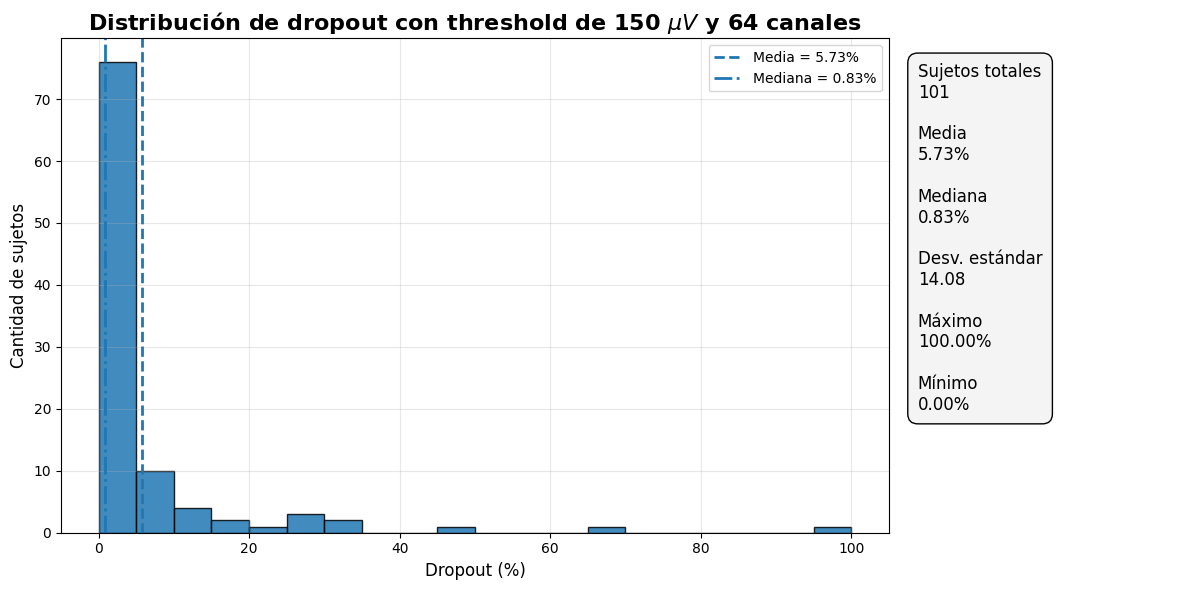

In [13]:
plot_dropout_report(
    csv_path="dropout_rate/101_subjects/7_channels/dropout_0.00015.csv",
    title="Distribución de dropout con threshold de 150 $\mu V$ y 64 canales",

)

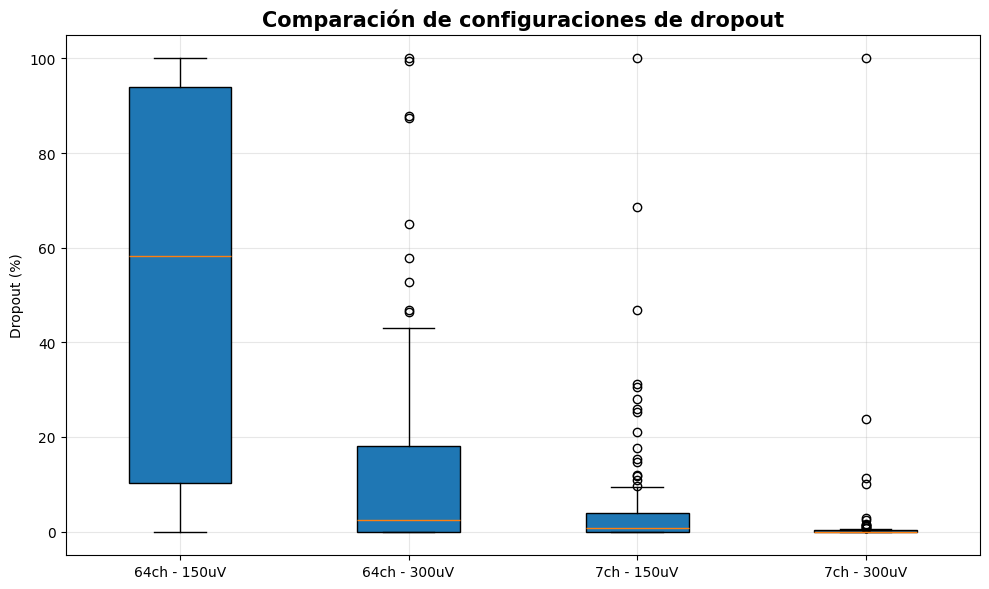

In [12]:
compare_dropout_configs([
    ("64ch - 150uV", "dropout_rate/101_subjects/all_channels/dropout_0.00015.csv"),
    ("64ch - 300uV", "dropout_rate/101_subjects/all_channels/dropout_0.0003.csv"),
    ("7ch - 150uV", "dropout_rate/101_subjects/7_channels/dropout_0.00015.csv"),
    ("7ch - 300uV", "dropout_rate/101_subjects/7_channels/dropout_0.0003.csv"),
])